## What are the most demanded skills for the top 3 most popular data roles?

#### Methodology

1. Clean-up skill column
2. Calculate skill count based on `job_title_short`
3. Calculate skill percentage
4. Plot final findings

### Import Libraries and Data

In [21]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
df = pd.read_csv('/Users/briceverola/Desktop/Le Wagon/job_postings_flat.csv')

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

### Filter Data for France

Filter the data for the market of France which is more meaningful for me

In [22]:
df_FR = df[df['job_country'] == 'France']

### Explode Skills

Each job can include multiple skills in a single field, which makes analysis difficult.  
To better understand skill demand, I transform the dataset so that each skill appears as a separate row, allowing for more accurate aggregation and comparison across roles.

In [23]:
df_skills = df_FR.explode('job_skills')

df_skills[['job_title', 'job_skills']]

,job_title,job_skills
63,Data Engineer Senior Google Cloud Platform (F/...,sql
63,Data Engineer Senior Google Cloud Platform (F/...,python
63,Data Engineer Senior Google Cloud Platform (F/...,watson
63,Data Engineer Senior Google Cloud Platform (F/...,gcp
63,Data Engineer Senior Google Cloud Platform (F/...,bigquery
...,...,...
1741715,Data Engineer Aws H/F,python
1741715,Data Engineer Aws H/F,elasticsearch
1741715,Data Engineer Aws H/F,aws
1741715,Data Engineer Aws H/F,airflow


### Count Skills per Job Title
To identify the most in-demand skills for each role, I count how often each skill appears within each job title.  
This allows me to highlight the key skills associated with each position and better understand role-specific requirements.

In [24]:
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

df_skills_count = df_skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1348,sql,Data Analyst,11560
1057,python,Data Engineer,11242
1058,python,Data Scientist,10736
1349,sql,Data Engineer,9975
1056,python,Data Analyst,8760
...,...,...,...
821,nltk,Software Engineer,1
1415,symfony,Business Analyst,1
204,cobol,Senior Data Analyst,1
696,lisp,Software Engineer,1


### Select Top 3 Data Roles

To focus the analysis on the most relevant positions, I select the three most common data roles: Data Analyst, Data Engineer, and Data Scientist.  
This ensures a meaningful comparison of skill requirements across the most in-demand roles in the data job market.

In [25]:
job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

### Compare Top Skills Across Roles

I visualize the top 5 most requested skills for each of the three main data roles to make comparisons more intuitive.  
This helps reveal which skills are shared across roles and which are more role-specific.

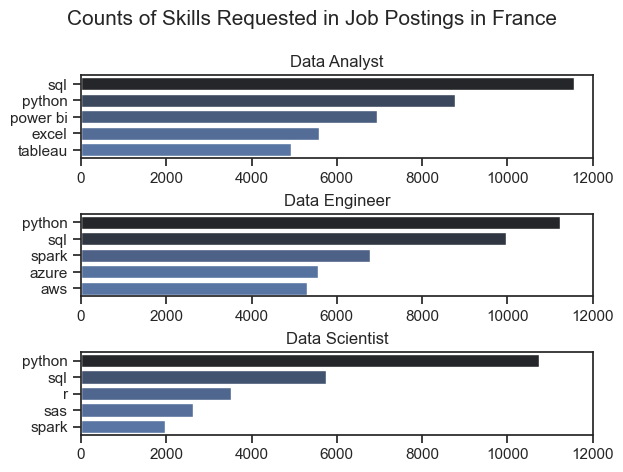

In [33]:
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)[::-1]
    sns.barplot(data=df_plot, x='skill_count', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 12000) # making the scales the same

fig.suptitle('Counts of Skills Requested in Job Postings in France', fontsize=15)
fig.tight_layout(h_pad=0.5)
plt.show()

### Convert Counts to Percentages

Counts alone don’t reflect how dominant a skill is across job postings.  
To make comparisons more meaningful, I convert counts into percentages relative to the total number of jobs per role.

In [27]:
df_job_title_count = df_FR['job_title_short'].value_counts().reset_index(name='jobs_total')

df_job_title_count

,job_title_short,jobs_total
0,Data Analyst,25333
1,Data Engineer,20194
2,Data Scientist,16811
3,Software Engineer,2758
4,Senior Data Engineer,2257
5,Business Analyst,2022
6,Senior Data Scientist,1986
7,Senior Data Analyst,1416
8,Machine Learning Engineer,1082
9,Cloud Engineer,834


Then I calculate the percentage of job postings that require each skill within each role to enable fair comparisons.  
This highlights how important each skill is relative to the total demand for that role.

In [28]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, on='job_title_short', how='left')

df_skills_perc['skill_percent'] = (df_skills_perc['skill_count'] / df_skills_perc['jobs_total']) * 100

df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,sql,Data Analyst,11560,25333,45.632179
1,python,Data Engineer,11242,20194,55.670001
2,python,Data Scientist,10736,16811,63.862947
3,sql,Data Engineer,9975,20194,49.395860
4,python,Data Analyst,8760,25333,34.579402
...,...,...,...,...,...
1643,nltk,Software Engineer,1,2758,0.036258
1644,symfony,Business Analyst,1,2022,0.049456
1645,cobol,Senior Data Analyst,1,1416,0.070621
1646,lisp,Software Engineer,1,2758,0.036258


### Visualize Skill Demand by Percentage

To better compare roles of different sizes, I visualize the top 5 skills by percentage for each of the three main data roles.  
This makes it easier to see which skills are most consistently requested within each role, beyond raw volume alone.

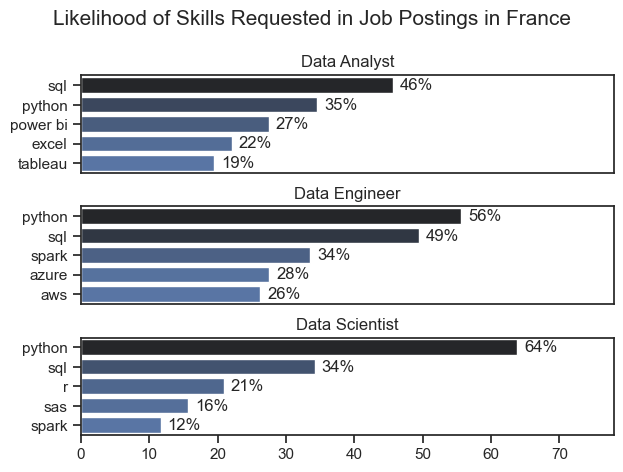

In [29]:
fig, ax = plt.subplots(len(job_titles), 1)


for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)
    # removing the x-axis tick labels for better readability
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

    # labeling the percentage on the bars
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Likelihood of Skills Requested in Job Postings in France', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()